# Kelman Filtering

In [3]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

# Add the libs directory to Python path
current_dir = os.path.dirname(os.path.abspath('KelmanFiltering.ipynb'))
libs_dir = os.path.join(current_dir, '..', 'libs')
libs_dir = os.path.abspath(libs_dir)
print("Libs directory:", libs_dir)
sys.path.insert(0, libs_dir)

from websocketclient import WebSocketCollector
from kelmanfilter import KalmanFilter


Libs directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/libs


In [5]:
ws_url = "ws://localhost:8000/ws"
message_queue = WebSocketCollector(ws_url, max_messages=100).collect()
print("Collected messages:", message_queue.qsize())

WebSocket opened
WebSocket closed
Collected messages: 100


In [6]:
print("Sample message:", message_queue.get())

raw_values = [message_queue.get() for _ in range(message_queue.qsize())]
values = [json.loads(value).get("data").get("value") for value in raw_values]
values = [float(value) for value in values if value is not None]
print("Extracted values:", values)

Sample message: {"type": "initial_state", "data": {"sensors": [{"id": "59e219b8-e38d-41c4-811a-d370c26ac176", "name": "Distance Sensor", "type": "custom", "interval": 0.1, "min_value": 0, "max_value": 100, "is_running": true, "current_value": 10.063984596560989, "recording": false, "parameters": {"actual_value": 10, "tolerance": 0.3}}, {"id": "f7db25d2-12e3-41a3-b952-d4b10cba6434", "name": "Velocity Sensor", "type": "custom", "interval": 0.1, "min_value": 0, "max_value": 100, "is_running": false, "current_value": 50.0, "recording": false, "parameters": {"actual_value": 5, "tolerance": 0.1}}], "mqtt_connected": false, "recordings": {}}}
Extracted values: [10.353385059640967, 10.296459304549712, 10.014167104464397, 9.98974531302151, 10.517051186846642, 10.746969974119613, 9.881278994513334, 10.589448897825166, 9.76909179609024, 10.10518825158911, 10.03347825319394, 9.79390283595253, 9.96388166317944, 10.031994534317407, 10.282551270605156, 9.910469010245007, 10.56243402787964, 9.46615857

In [7]:
# Enhanced Kalman filter using class
if 'values' in locals() and values:
    # Use advanced Kalman filter with velocity estimation
    kf = KalmanFilter(dt=1.0, 
                       process_variance=1e-5, 
                       measurement_variance=1e-2,
                       initial_position=values[0],
                       initial_velocity=0.0)
    
    filtered_values, velocities = kf.filter(values)
    
    print("=== Kalman Filter Results ===")
    print(f"Raw values (first 10): {values[:10]}")
    print(f"Filtered values (first 10): {[f'{v:.4f}' for v in filtered_values[:10]]}")
    print(f"Estimated velocities (first 10): {[f'{v:.4f}' for v in velocities[:10]]}")
    print(f"Mean squared error (Filter vs Raw): {np.mean([(f - r)**2 for f, r in zip(filtered_values, values)]):.6f}")


=== Kalman Filter Results ===
Raw values (first 10): [10.353385059640967, 10.296459304549712, 10.014167104464397, 9.98974531302151, 10.517051186846642, 10.746969974119613, 9.881278994513334, 10.589448897825166, 9.76909179609024, 10.10518825158911]
Filtered values (first 10): ['10.3534', '10.2975', '10.0539', '9.9586', '10.2382', '10.5056', '10.2550', '10.3945', '10.1729', '10.1377']
Estimated velocities (first 10): ['0.0000', '-0.0543', '-0.1668', '-0.1363', '0.0021', '0.0746', '-0.0010', '0.0275', '-0.0177', '-0.0206']
Mean squared error (Filter vs Raw): 0.072685


(array([ 2.,  0.,  0.,  0.,  3.,  2.,  3.,  3.,  7.,  3.,  4.,  9.,  9.,
         5., 10.,  5.,  5.,  3.,  3.,  6.,  5.,  1.,  3.,  1.,  4.,  0.,
         0.,  2.,  0.,  1.]),
 array([ 9.21576442,  9.27156812,  9.32737182,  9.38317552,  9.43897922,
         9.49478292,  9.55058663,  9.60639033,  9.66219403,  9.71799773,
         9.77380143,  9.82960513,  9.88540884,  9.94121254,  9.99701624,
        10.05281994, 10.10862364, 10.16442734, 10.22023104, 10.27603475,
        10.33183845, 10.38764215, 10.44344585, 10.49924955, 10.55505325,
        10.61085696, 10.66666066, 10.72246436, 10.77826806, 10.83407176,
        10.88987546]),
 <BarContainer object of 30 artists>)

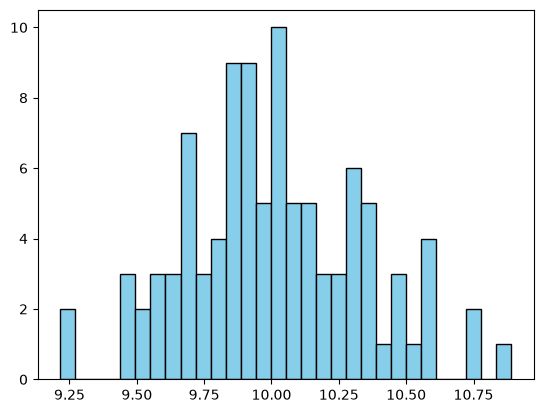

WebSocket closed
WebSocket closed


In [8]:
plt.hist(values, bins=30, color='skyblue', edgecolor='black')